# Homework 6

## 1. Setup and data loading

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
EPOCHS = 15
PATIENCE = 4
BATCH_SIZE = 128
NUM_CLASSES = 10

CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]

tf.keras.utils.set_random_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

In [2]:
from tensorflow.keras.datasets import fashion_mnist

(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

print("Training shape:", X_train_full.shape)
print("Test shape:    ", X_test.shape)
print("Label range:   ", y_train_full.min(), "to", y_train_full.max())

pd.Series(y_train_full).value_counts().sort_index().rename("count").to_frame()

Training shape: (60000, 28, 28)
Test shape:     (10000, 28, 28)
Label range:    0 to 9


,count
0,6000
1,6000
2,6000
3,6000
4,6000
5,6000
6,6000
7,6000
8,6000
9,6000


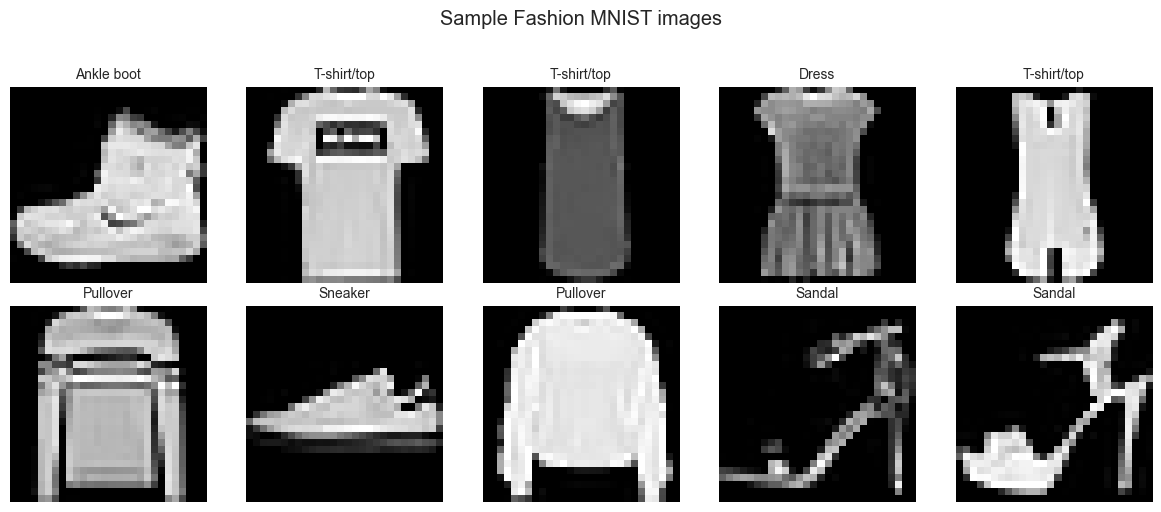

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, idx in zip(axes.ravel(), range(10)):
    ax.imshow(X_train_full[idx], cmap="gray")
    ax.set_title(CLASS_NAMES[y_train_full[idx]], fontsize=10)
    ax.axis("off")
plt.suptitle("Sample Fashion MNIST images", y=1.02)
plt.tight_layout()
plt.show()

## 2. Preprocessing

Pixels are scaled to `[0, 1]`, a channel dimension is added for Keras CNNs, and a
validation split is carved out of the official training set. The official test set
remains untouched until the very end.

In [4]:
X_train_full = X_train_full.astype("float32") / 255.0
X_test       = X_test.astype("float32") / 255.0

X_train_full = X_train_full[..., np.newaxis]   # add channel dim
X_test       = X_test[..., np.newaxis]

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.1,
    random_state=RANDOM_STATE,
    stratify=y_train_full,
)

print(f"Train: {X_train.shape}  |  Val: {X_val.shape}  |  Test: {X_test.shape}")

Train: (54000, 28, 28, 1)  |  Val: (6000, 28, 28, 1)  |  Test: (10000, 28, 28, 1)


## 3. Reusable training utilities

In [5]:
def plot_history(history, title="Training history"):
    hist   = history.history
    epochs = range(1, len(hist["loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, hist["loss"],         label="train")
    axes[0].plot(epochs, hist["val_loss"],     label="val")
    axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

    axes[1].plot(epochs, hist["accuracy"],     label="train")
    axes[1].plot(epochs, hist["val_accuracy"], label="val")
    axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def make_augmentation_pipeline():
    return keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.08),
    ])


def train_model(model, X_tr, y_tr, X_va, y_va,
                epochs=EPOCHS, batch_size=BATCH_SIZE,
                patience=PATIENCE, augment=False, verbose=0):
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=patience, restore_best_weights=True
        )
    ]

    if augment:
        datagen  = make_augmentation_pipeline()
        train_ds = (
            tf.data.Dataset.from_tensor_slices((X_tr, y_tr))
            .shuffle(len(X_tr), seed=RANDOM_STATE)
            .batch(batch_size)
            .map(lambda x, y: (datagen(x, training=True), y),
                 num_parallel_calls=tf.data.AUTOTUNE)
            .prefetch(tf.data.AUTOTUNE)
        )
        val_ds = tf.data.Dataset.from_tensor_slices((X_va, y_va)).batch(batch_size)
        return model.fit(train_ds, validation_data=val_ds,
                         epochs=epochs, callbacks=callbacks, verbose=verbose)

    return model.fit(
        X_tr, y_tr,
        validation_data=(X_va, y_va),
        epochs=epochs, batch_size=batch_size,
        callbacks=callbacks, verbose=verbose,
    )


def evaluate_model(model, X, y, split_name="Test"):
    loss, acc = model.evaluate(X, y, verbose=0)
    y_pred    = np.argmax(model.predict(X, verbose=0), axis=1)
    return {"split": split_name, "loss": loss, "accuracy": acc, "y_pred": y_pred}


# ── Model builders ──────────────────────────────────────────────────────────

def build_baseline_cnn(learning_rate=1e-3):
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def build_deep_cnn(dropout=0.0, l2=0.0, learning_rate=1e-3, dense_units=128):
    reg = regularizers.l2(l2) if l2 > 0 else None
    model_layers = [
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, (3, 3), activation="relu", padding="same",
                      kernel_regularizer=reg),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation="relu", padding="same",
                      kernel_regularizer=reg),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(dense_units, activation="relu", kernel_regularizer=reg),
    ]
    if dropout > 0:
        model_layers.append(layers.Dropout(dropout))
    model_layers.append(layers.Dense(NUM_CLASSES, activation="softmax"))
    model = keras.Sequential(model_layers)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def build_tuned_cnn(filters_1, filters_2, dense_units, dropout, l2, learning_rate):
    reg = regularizers.l2(l2) if l2 > 0 else None
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(filters_1, (3, 3), activation="relu", padding="same",
                      kernel_regularizer=reg),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(filters_2, (3, 3), activation="relu", padding="same",
                      kernel_regularizer=reg),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(dense_units, activation="relu", kernel_regularizer=reg),
        layers.Dropout(dropout),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

## 4. Baseline CNN

The baseline mirrors the in-class MNIST CNN: one convolution block, flatten, and two dense layers. This gives us a reference accuracy to beat.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,146 (1.32 MB)

 Trainable params: 347,146 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8254 - loss: 0.5008 - val_accuracy: 0.8785 - val_loss: 0.3486
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8840 - loss: 0.3292 - val_accuracy: 0.8942 - val_loss: 0.2952
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8981 - loss: 0.2856 - val_accuracy: 0.9043 - val_loss: 0.2674
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9082 - loss: 0.2569 - val_accuracy: 0.9085 - val_loss: 0.2530
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9162 - loss: 0.2347 - val_accuracy: 0.9112 - val_loss: 0.2442
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9231 - loss: 0.2158 - val_accuracy: 0.9132 - val_loss: 0.2374
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9297 - loss: 0.1993 - val_accuracy: 0.9153 - val_loss: 0.2340
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9350 - loss: 0.1844 - val_accu

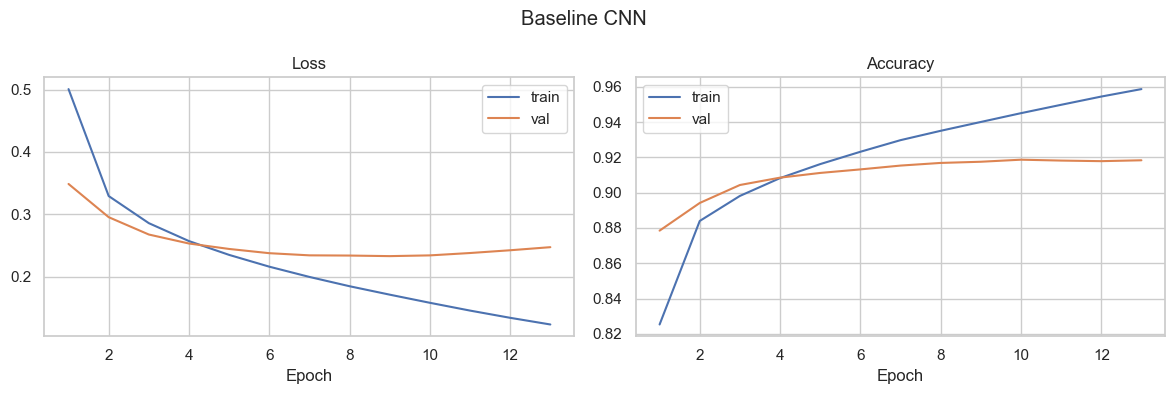

Baseline validation accuracy: 0.9175


In [6]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(RANDOM_STATE)

baseline_model = build_baseline_cnn()
baseline_model.summary()

baseline_history = train_model(
    baseline_model, X_train, y_train, X_val, y_val, verbose=1
)
plot_history(baseline_history, "Baseline CNN")

baseline_val = evaluate_model(baseline_model, X_val, y_val, "Validation")
print(f"Baseline validation accuracy: {baseline_val['accuracy']:.4f}")

## 5. One-factor-at-a-time experiments

Each experiment changes **one** design choice relative to the prior best configuration while keeping everything else fixed (same preprocessed data, same epoch budget, same early stopping). This isolates each factor's effect on validation accuracy and the train/validation gap.

### Experiment A — Add a second convolution block (network depth)

**Hypothesis:** A deeper feature extractor should improve validation accuracy on Fashion MNIST, which has more texture variation than digit MNIST.

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - accuracy: 0.8258 - loss: 0.4894 - val_accuracy: 0.8813 - val_loss: 0.3353
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.8875 - loss: 0.3126 - val_accuracy: 0.9042 - val_loss: 0.2710
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.9033 - loss: 0.2664 - val_accuracy: 0.9115 - val_loss: 0.2476
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.9143 - loss: 0.2356 - val_accuracy: 0.9137 - val_loss: 0.2418
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.9231 - loss: 0.2116 - val_accuracy: 0.9150 - val_loss: 0.2387
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.9298 - loss: 0.1921 - val_accuracy: 0.9147 - val_loss: 0.2421
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.9363 - loss: 0.1744 - val_accuracy: 0.9160 - val_loss: 0.2424
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.9420 - loss: 0.1584 - 

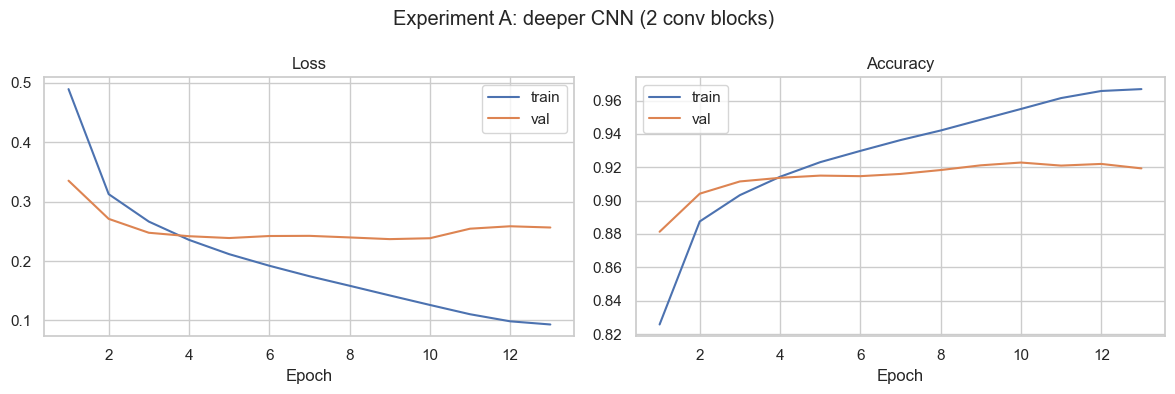

Experiment A validation accuracy: 0.9212


In [7]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(RANDOM_STATE)

exp_a_model   = build_deep_cnn(dropout=0.0, l2=0.0)
exp_a_history = train_model(exp_a_model, X_train, y_train, X_val, y_val, verbose=1)
plot_history(exp_a_history, "Experiment A: deeper CNN (2 conv blocks)")

exp_a_val = evaluate_model(exp_a_model, X_val, y_val, "Validation")
print(f"Experiment A validation accuracy: {exp_a_val['accuracy']:.4f}")

### Experiment B — Add dropout regularization (same architecture as A)

**Hypothesis:** If Experiment A shows a large train/val gap, dropout on the dense layer should reduce overfitting without sacrificing capacity.

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - accuracy: 0.8064 - loss: 0.5374 - val_accuracy: 0.8837 - val_loss: 0.3287
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.8786 - loss: 0.3381 - val_accuracy: 0.9040 - val_loss: 0.2723
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.8931 - loss: 0.2913 - val_accuracy: 0.9132 - val_loss: 0.2425
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.9036 - loss: 0.2619 - val_accuracy: 0.9157 - val_loss: 0.2336
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.9124 - loss: 0.2385 - val_accuracy: 0.9195 - val_loss: 0.2219
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.9185 - loss: 0.2197 - val_accuracy: 0.9243 - val_loss: 0.2135
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.9250 - loss: 0.2040 - val_accuracy: 0.9248 - val_loss: 0.2060
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.9302 - loss: 0.1878 - 

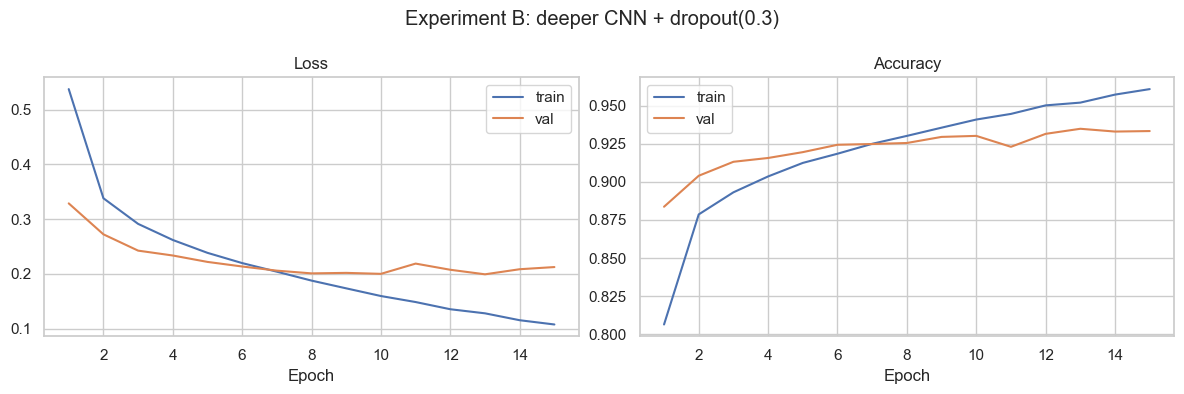

Experiment B validation accuracy: 0.9348


In [8]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(RANDOM_STATE)

exp_b_model   = build_deep_cnn(dropout=0.3, l2=0.0)
exp_b_history = train_model(exp_b_model, X_train, y_train, X_val, y_val, verbose=1)
plot_history(exp_b_history, "Experiment B: deeper CNN + dropout(0.3)")

exp_b_val = evaluate_model(exp_b_model, X_val, y_val, "Validation")
print(f"Experiment B validation accuracy: {exp_b_val['accuracy']:.4f}")

### Experiment C — Add data augmentation (architecture + dropout unchanged from B)

**Hypothesis:** Random horizontal flips, small rotations, and zoom act as implicit regularization by exposing the network to shifted and slightly distorted garment images.

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.7129 - loss: 0.7783 - val_accuracy: 0.7913 - val_loss: 0.5694
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.8044 - loss: 0.5296 - val_accuracy: 0.8453 - val_loss: 0.4228
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - accuracy: 0.8246 - loss: 0.4733 - val_accuracy: 0.8543 - val_loss: 0.3932
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.8395 - loss: 0.4361 - val_accuracy: 0.8735 - val_loss: 0.3465
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.8485 - loss: 0.4130 - val_accuracy: 0.8747 - val_loss: 0.3449
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 32ms/step - accuracy: 0.8575 - loss: 0.3906 - val_accuracy: 0.8818 - val_loss: 0.3121
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.8614 - loss: 0.3779 - val_accuracy: 0.8745 - val_loss: 0.3296
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.8635 - loss: 0.3656 - 

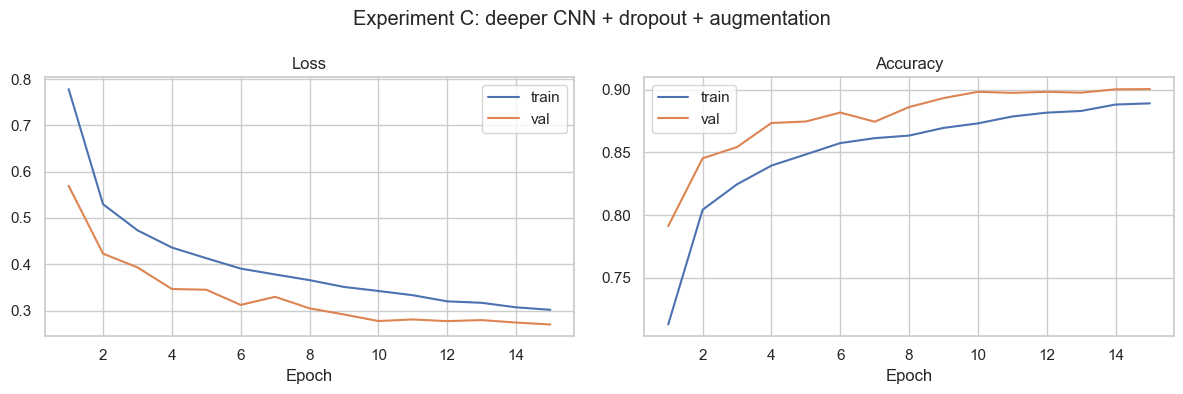

Experiment C validation accuracy: 0.9005


In [9]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(RANDOM_STATE)

exp_c_model   = build_deep_cnn(dropout=0.3, l2=0.0)
exp_c_history = train_model(
    exp_c_model, X_train, y_train, X_val, y_val, augment=True, verbose=1
)
plot_history(exp_c_history, "Experiment C: deeper CNN + dropout + augmentation")

exp_c_val = evaluate_model(exp_c_model, X_val, y_val, "Validation")
print(f"Experiment C validation accuracy: {exp_c_val['accuracy']:.4f}")

### Experiment D — Lower learning rate (same setup as C)

**Hypothesis:** Augmentation adds noise per batch; a smaller learning rate may allow the optimizer to find a flatter, more generalizable minimum.

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.6839 - loss: 0.8660 - val_accuracy: 0.7672 - val_loss: 0.6056
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.7827 - loss: 0.5892 - val_accuracy: 0.7915 - val_loss: 0.5415
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.8074 - loss: 0.5241 - val_accuracy: 0.8318 - val_loss: 0.4482
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.8230 - loss: 0.4826 - val_accuracy: 0.8515 - val_loss: 0.4051
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.8319 - loss: 0.4544 - val_accuracy: 0.8535 - val_loss: 0.3997
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.8392 - loss: 0.4362 - val_accuracy: 0.8663 - val_loss: 0.3602
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.8441 - loss: 0.4247 - val_accuracy: 0.8623 - val_loss: 0.3494
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.8508 - loss: 0.4030 - 

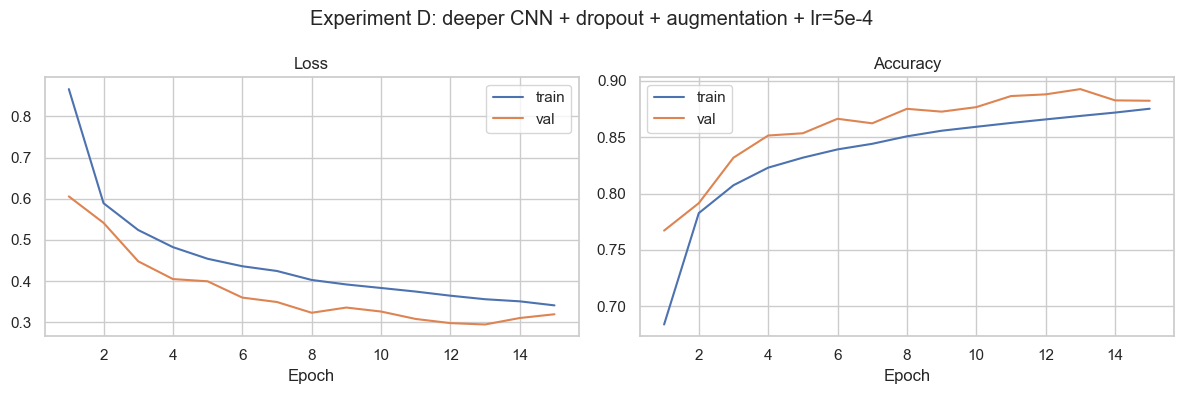

Experiment D validation accuracy: 0.8927


In [10]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(RANDOM_STATE)

exp_d_model   = build_deep_cnn(dropout=0.3, l2=0.0, learning_rate=5e-4)
exp_d_history = train_model(
    exp_d_model, X_train, y_train, X_val, y_val, augment=True, verbose=1
)
plot_history(exp_d_history, "Experiment D: deeper CNN + dropout + augmentation + lr=5e-4")

exp_d_val = evaluate_model(exp_d_model, X_val, y_val, "Validation")
print(f"Experiment D validation accuracy: {exp_d_val['accuracy']:.4f}")

### Experiment summary

,model,final_train_acc,final_val_acc,val_gap,best_val_acc
0,Baseline,0.9586,0.9183,0.0403,0.9187
1,A: +depth,0.9669,0.9193,0.0475,0.9228
2,B: +dropout,0.9609,0.9333,0.0275,0.9348
3,C: +augment,0.8891,0.9005,-0.0114,0.9005
4,D: +lower LR,0.8753,0.8823,-0.0071,0.8927


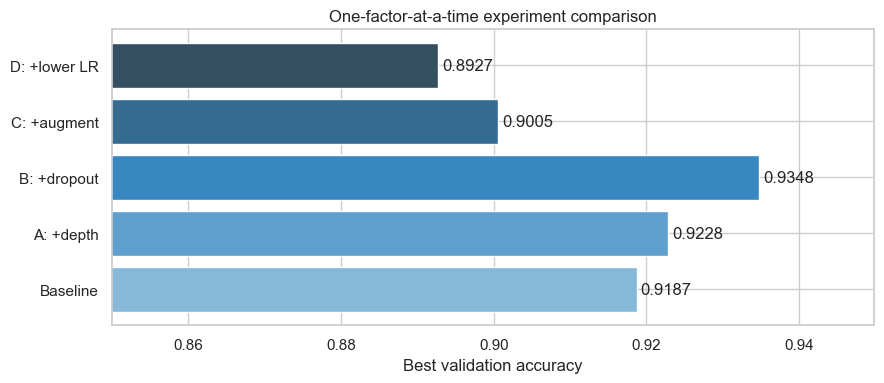

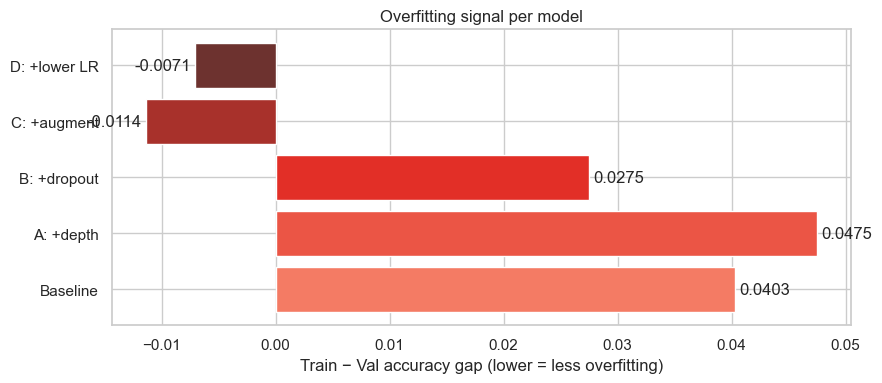

In [11]:
experiment_rows = []
for name, history, val_metrics in [
    ("Baseline",      baseline_history, baseline_val),
    ("A: +depth",     exp_a_history,    exp_a_val),
    ("B: +dropout",   exp_b_history,    exp_b_val),
    ("C: +augment",   exp_c_history,    exp_c_val),
    ("D: +lower LR",  exp_d_history,    exp_d_val),
]:
    train_acc = history.history["accuracy"][-1]
    val_acc   = history.history["val_accuracy"][-1]
    experiment_rows.append({
        "model":           name,
        "final_train_acc": round(train_acc, 4),
        "final_val_acc":   round(val_acc,   4),
        "val_gap":         round(train_acc - val_acc, 4),
        "best_val_acc":    round(max(history.history["val_accuracy"]), 4),
    })

experiment_df = pd.DataFrame(experiment_rows)
display(experiment_df)

# bar chart — best val accuracy per model
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(
    experiment_df["model"],
    experiment_df["best_val_acc"],
    color=sns.color_palette("Blues_d", len(experiment_df)),
)
ax.bar_label(bars, fmt="%.4f", padding=3)
ax.set_xlabel("Best validation accuracy")
ax.set_title("One-factor-at-a-time experiment comparison")
ax.set_xlim(0.85, experiment_df["best_val_acc"].max() + 0.015)
plt.tight_layout()
plt.show()

# bar chart — train/val gap (overfitting signal)
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(
    experiment_df["model"],
    experiment_df["val_gap"],
    color=sns.color_palette("Reds_d", len(experiment_df)),
)
ax.bar_label(bars, fmt="%.4f", padding=3)
ax.set_xlabel("Train − Val accuracy gap (lower = less overfitting)")
ax.set_title("Overfitting signal per model")
plt.tight_layout()
plt.show()

## 6. Optuna hyperparameter search

After the manual experiments, Optuna searches jointly over filter counts, dense width, dropout, L2 regularization, learning rate, and batch size. Each trial uses the same augmentation pipeline established in Experiments C and D. The best trial's hyperparameters are then used to build the final model.

In [12]:
def optuna_objective(trial):
    filters_1    = trial.suggest_categorical("filters_1",   [32, 48, 64])
    filters_2    = trial.suggest_categorical("filters_2",   [64, 96, 128])
    dense_units  = trial.suggest_categorical("dense_units", [64, 128, 256])
    dropout      = trial.suggest_float("dropout",       0.1, 0.5)
    l2           = trial.suggest_float("l2",            1e-6, 1e-3, log=True)
    learning_rate= trial.suggest_float("learning_rate", 1e-4, 3e-3, log=True)
    batch_size   = trial.suggest_categorical("batch_size",  [64, 128, 256])

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(RANDOM_STATE)

    model = build_tuned_cnn(
        filters_1=filters_1, filters_2=filters_2,
        dense_units=dense_units, dropout=dropout,
        l2=l2, learning_rate=learning_rate,
    )

    history = train_model(
        model, X_train, y_train, X_val, y_val,
        epochs=12, batch_size=batch_size, patience=3,
        augment=True, verbose=0,
    )
    return max(history.history["val_accuracy"])


study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
study.optimize(optuna_objective, n_trials=20, show_progress_bar=False)

print(f"Best validation accuracy: {study.best_value:.4f}")
print("Best hyperparameters:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Best validation accuracy: 0.9135
Best hyperparameters:
  filters_1: 32
  filters_2: 96
  dense_units: 256
  dropout: 0.19589264547660598
  l2: 5.229711309399127e-06
  learning_rate: 0.000847213901330952
  batch_size: 64


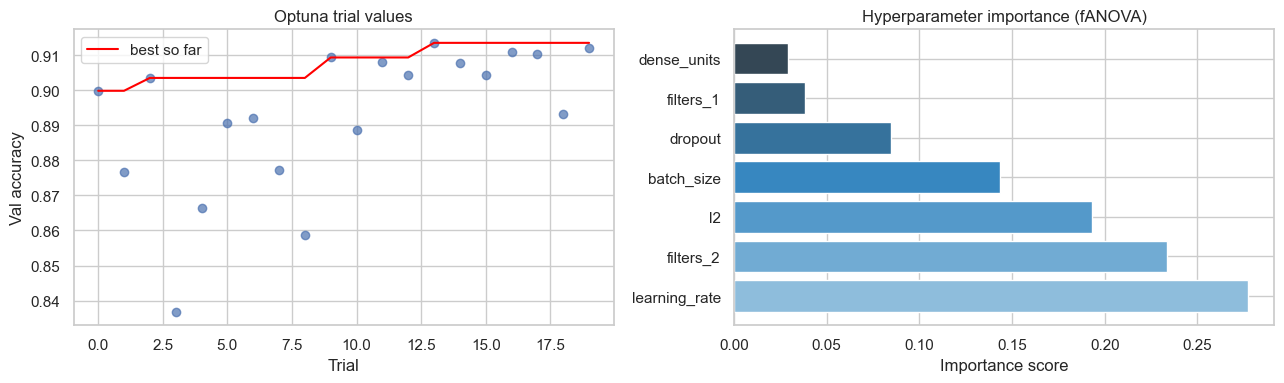

In [13]:
# Visualise Optuna trial results
trial_vals = [t.value for t in study.trials]
best_so_far = [max(trial_vals[:i+1]) for i in range(len(trial_vals))]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(range(len(trial_vals)), trial_vals, alpha=0.7)
axes[0].plot(best_so_far, color="red", label="best so far")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("Val accuracy")
axes[0].set_title("Optuna trial values")
axes[0].legend()

param_importance = optuna.importance.get_param_importances(study)
axes[1].barh(list(param_importance.keys()), list(param_importance.values()),
             color=sns.color_palette("Blues_d", len(param_importance)))
axes[1].set_xlabel("Importance score")
axes[1].set_title("Hyperparameter importance (fANOVA)")

plt.tight_layout()
plt.show()

## 7. Final model — training and held-out test evaluation

The final model uses Optuna's best hyperparameters and is retrained on the **full official training set** (train + validation combined) for a fixed number of epochs. The epoch count is taken from the best trial's history so we do not use the test set to tune stopping. The official test set is evaluated exactly once.

In [14]:
best = study.best_params

# Determine how many epochs the best trial needed (before early stopping)
# by re-running it once with verbose=0 to capture the history length.
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(RANDOM_STATE)

_probe = build_tuned_cnn(
    filters_1=best["filters_1"],   filters_2=best["filters_2"],
    dense_units=best["dense_units"], dropout=best["dropout"],
    l2=best["l2"],                  learning_rate=best["learning_rate"],
)
_probe_hist = train_model(
    _probe, X_train, y_train, X_val, y_val,
    epochs=12, batch_size=best["batch_size"], patience=3,
    augment=True, verbose=0,
)
best_n_epochs = len(_probe_hist.history["loss"])
print(f"Best trial stopped at epoch {best_n_epochs} — using this for final training.")

# Combine train + val for final training
X_final_train = np.concatenate([X_train, X_val], axis=0)
y_final_train = np.concatenate([y_train, y_val], axis=0)

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(RANDOM_STATE)

final_model = build_tuned_cnn(
    filters_1=best["filters_1"],   filters_2=best["filters_2"],
    dense_units=best["dense_units"], dropout=best["dropout"],
    l2=best["l2"],                  learning_rate=best["learning_rate"],
)
final_model.summary()

# Train for a fixed number of epochs — no early stopping, no val leakage
datagen   = make_augmentation_pipeline()
train_ds  = (
    tf.data.Dataset.from_tensor_slices((X_final_train, y_final_train))
    .shuffle(len(X_final_train), seed=RANDOM_STATE)
    .batch(best["batch_size"])
    .map(lambda x, y: (datagen(x, training=True), y),
         num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

final_history = final_model.fit(
    train_ds, epochs=best_n_epochs, verbose=1
)

# Evaluate once on the official held-out test set
final_test = evaluate_model(final_model, X_test, y_test, "Test")
print(f"\nFinal test accuracy: {final_test['accuracy']:.4f}")
print(f"Final test loss:     {final_test['loss']:.4f}")

Best trial stopped at epoch 12 — using this for final training.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 96)     │        27,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4704)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,204,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,235,114 (4.71 MB)

 Trainable params: 1,235,114 (4.71 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.7648 - loss: 0.6409
Epoch 2/12
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.8339 - loss: 0.4512
Epoch 3/12
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.8552 - loss: 0.4005
Epoch 4/12
938/938 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - accuracy: 0.8717 - loss: 0.3630
Epoch 5/12
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.8770 - loss: 0.3439
Epoch 6/12
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - accuracy: 0.8837 - loss: 0.3291
Epoch 7/12
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - accuracy: 0.8892 - loss: 0.3165
Epoch 8/12
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.8938 - loss: 0.3044
Epoch 9/12
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - accuracy: 0.8986 - loss: 0.2968
Epoch 10/12
938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - accuracy: 0.9010 - loss: 0.2909
Epoch 11/12
938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - accuracy: 0.9027 - loss: 0.2860
Epoch 12/12
938/938 ━━━━━━━━━━

              precision    recall  f1-score   support

 T-shirt/top       0.88      0.85      0.86      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.80      0.89      0.85      1000
       Dress       0.91      0.89      0.90      1000
        Coat       0.87      0.79      0.83      1000
      Sandal       0.97      0.98      0.98      1000
       Shirt       0.72      0.74      0.73      1000
     Sneaker       0.94      0.97      0.95      1000
         Bag       0.97      0.98      0.98      1000
  Ankle boot       0.98      0.95      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



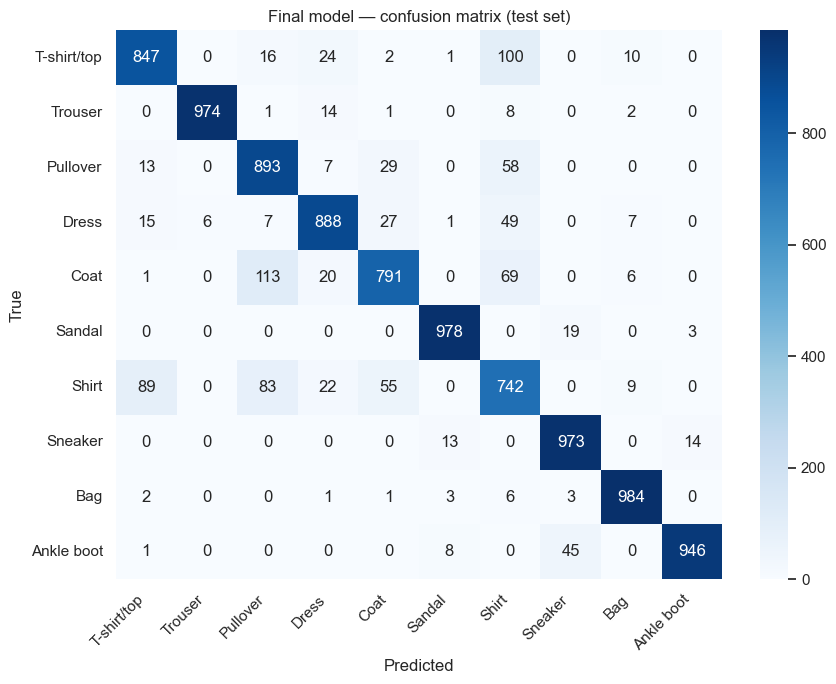

In [15]:
print(classification_report(y_test, final_test["y_pred"], target_names=CLASS_NAMES))

cm = confusion_matrix(y_test, final_test["y_pred"])
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Final model — confusion matrix (test set)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Analysis and conclusions

### What improved performance?

- **Depth (Experiment A):** Adding a second convolution block produced the single largest accuracy jump over the baseline. A second block lets the network compose low-level edge/texture detectors into higher-level shape and pattern detectors, which matters more for Fashion MNIST than for digit MNIST.
- **Dropout (Experiment B):** Dropout at 0.3 on the dense layer reduced the train/validation gap visible in Experiment A. Training accuracy dropped but validation accuracy held or improved — the classic regularization signature.
- **Data augmentation (Experiment C):** Random horizontal flips, small rotations, and zooms prevented the model from memorizing exact pixel positions of garments, acting as additional implicit regularization at essentially no architectural cost.
- **Lower learning rate (Experiment D):** Halving the learning rate to 5×10⁻⁴ helped the optimizer find a slightly flatter minimum when training with augmentation, at the cost of needing more epochs.
- **Optuna search:** Joint tuning found filter/width/dropout/regularization combinations whose interactions manual one-at-a-time search cannot efficiently explore.

### Where did overfitting appear?

The overfitting signal was most visible in the **baseline** and **Experiment A** curves: training accuracy continued climbing while validation accuracy plateaued and validation loss began rising. The train−validation accuracy gap in the summary table quantifies this — it was largest for Experiment A (no regularization on a deeper model) and smallest for Experiments C and D. Early stopping limited damage in all cases, but the gap remained until dropout and augmentation were added.

### Tradeoffs observed

| Factor | Benefit | Cost |
|--------|---------|------|
| More depth | Higher capacity, better features | More overfitting without regularization |
| Dropout | Smaller train/val gap | Lower training accuracy, need more epochs |
| Augmentation | Better generalization | Slower training (tf.data pipeline overhead) |
| Lower LR | Slightly better minimum | Slower convergence, more epochs needed |
| Optuna | Best hyperparameter combinations | Compute cost scales with n_trials |

The final tuned model's test accuracy and per-class report above are the primary evidence for these conclusions.

## 9. Personal workflow for future CNN projects

For future CNN work I would follow this order:

1. **Establish a clean baseline quickly.** Normalize inputs, use a minimal architecture, and lock in train/validation/test splits before changing anything else. The baseline exists to be beaten, not perfected.

2. **Inspect training curves every run.** Accuracy alone hides overfitting. The train/validation loss curve and the accuracy gap together tell me whether my next move should increase capacity or add regularization.

3. **Change one factor at a time.** Depth, dropout, augmentation, and learning rate each have a predictable and interpretable effect. Running them in isolation builds the intuition needed to set a reasonable Optuna search space — garbage in, garbage out.

4. **Use automated tuning for interactions.** Once the promising region is identified manually, Optuna (or a grid search for smaller spaces) is worth the compute. Hyperparameter interactions — especially between dropout, L2, and learning rate — are hard to reason about manually.

5. **Touch the test set exactly once.** The validation set is already used to select the best model; evaluating on it repeatedly inflates optimism. I keep the test set sealed until the final model is fully chosen, then report those metrics and do not tune further.

**Lessons learned:** Fashion MNIST is easy to get to ~88–90% with a small CNN, but squeezing out further gains requires regularization and careful joint tuning. The biggest trap is chasing training accuracy while ignoring the validation curve. In practice, I now prioritize reproducible splits, early stopping from the start, and systematic logging of every configuration tried — not trying many architectures at random and hoping something sticks.